In [1]:
import xarray as xr

In [2]:
df_uo = xr.open_dataset("../data/raw/adriatic_currents_uo_detided_2023_2024.nc")
df_vo = xr.open_dataset("../data/raw/adriatic_currents_vo_detided_2023_2024.nc")


In [3]:
df_uo

<xarray.Dataset> Size: 80MB
Dimensions:     (time: 731, latitude: 142, longitude: 193)
Coordinates:
  * time        (time) datetime64[ns] 6kB 2023-01-01 2023-01-02 ... 2024-12-31
  * latitude    (latitude) float32 568B 40.02 40.06 40.1 ... 45.81 45.85 45.9
  * longitude   (longitude) float32 772B 12.0 12.04 12.08 ... 19.92 19.96 20.0
Data variables:
    uo_detided  (time, latitude, longitude) float32 80MB ...
Attributes:
    comment:                   Please check in CMEMS catalogue the INFO secti...
    title:                     Sea Surface Horizontal Velocity Assuming No Ti...
    Conventions:               CF-1.8
    source:                    MedFS EAS9
    contact:                   servicedesk.cmems@mercator-ocean.eu
    references:                Please check in CMEMS catalogue the INFO secti...
    institution:               Centro Euro-Mediterraneo sui Cambiamenti Clima...
    copernicusmarine_version:  2.2.3

In [4]:
df_vo

<xarray.Dataset> Size: 80MB
Dimensions:     (time: 731, latitude: 142, longitude: 193)
Coordinates:
  * time        (time) datetime64[ns] 6kB 2023-01-01 2023-01-02 ... 2024-12-31
  * latitude    (latitude) float32 568B 40.02 40.06 40.1 ... 45.81 45.85 45.9
  * longitude   (longitude) float32 772B 12.0 12.04 12.08 ... 19.92 19.96 20.0
Data variables:
    vo_detided  (time, latitude, longitude) float32 80MB ...
Attributes:
    comment:                   Please check in CMEMS catalogue the INFO secti...
    title:                     Sea Surface Horizontal Velocity Assuming No Ti...
    Conventions:               CF-1.8
    source:                    MedFS EAS9
    contact:                   servicedesk.cmems@mercator-ocean.eu
    references:                Please check in CMEMS catalogue the INFO secti...
    institution:               Centro Euro-Mediterraneo sui Cambiamenti Clima...
    copernicusmarine_version:  2.2.3

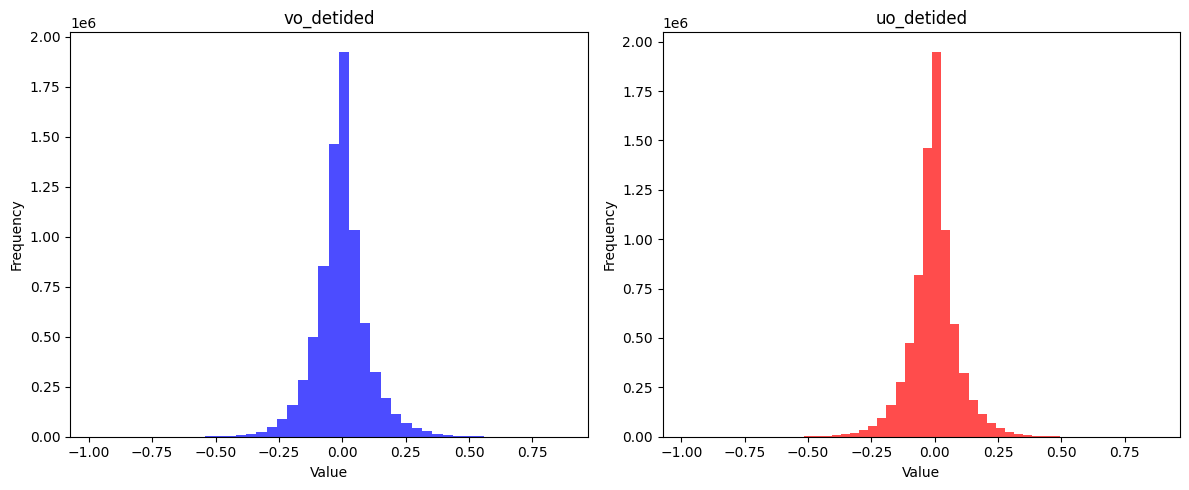

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Flatten and remove NaNs
vo_data = df_vo['vo_detided'].values.flatten()
vo_data = vo_data[~np.isnan(vo_data)]

uo_data = df_uo['uo_detided'].values.flatten()
uo_data = uo_data[~np.isnan(uo_data)]

# Determine shared x-axis limits
xmin = min(vo_data.min(), uo_data.min())
xmax = max(vo_data.max(), uo_data.max())

# Plot side-by-side histograms
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(vo_data, bins=50, color='blue', alpha=0.7)
axes[0].set_title("vo_detided")
axes[0].set_xlabel("Value")
axes[0].set_ylabel("Frequency")
axes[0].set_xlim(xmin, xmax)

axes[1].hist(uo_data, bins=50, color='red', alpha=0.7)
axes[1].set_title("uo_detided")
axes[1].set_xlabel("Value")
axes[1].set_ylabel("Frequency")
axes[1].set_xlim(xmin, xmax)

plt.tight_layout()
plt.show()


In [6]:
len(vo_data), len(uo_data)

(7785881, 7785881)

In [7]:
import numpy as np
da = df_uo["uo_detided"] 

percent_none = np.isnan(da).sum() / da.size * 100
print(f"Procent of None value fo uo: {percent_none:.2f}%")

Procent of None value fo uo: 61.14%


In [8]:
import numpy as np
da = df_vo["vo_detided"] 

percent_none = np.isnan(da).sum() / da.size * 100
print(f"Procent of None value for vo: {percent_none:.2f}%")

Procent of None value for vo: 61.14%


In [9]:
number_of_none_sample = da.size - np.isnan(da).sum()
print(f"Number of none samples: {number_of_none_sample.item()}")

Number of none samples: 7785881


In [13]:
import hvplot.pandas

df_vo[['longitude', 'latitude']].to_dataframe().hvplot.scatter(
    x='longitude', y='latitude',
    size=2, color='black', alpha=0.5
)

:Scatter   [longitude]   (latitude)

In [14]:
df_points = df_vo[['longitude', 'latitude', 'vo_detided']].to_dataframe()

# Keep only rows where 'vo_detided' is not NaN
df_points = df_points[df_points['vo_detided'].notna()]

# Plot
df_points.hvplot.scatter(
    x='longitude',
    y='latitude',
    size=2,
    color='black',
    alpha=0.5
)


:Scatter   [longitude]   (latitude)

In [ ]:
print(df_vo.dims)
print(df_vo.coords)


FrozenMappingWarningOnValuesAccess({'time': 731, 'latitude': 142, 'longitude': 193})
Coordinates:
  * latitude   (latitude) float32 568B 40.02 40.06 40.1 ... 45.81 45.85 45.9
  * longitude  (longitude) float32 772B 12.0 12.04 12.08 ... 19.92 19.96 20.0
  * time       (time) datetime64[ns] 6kB 2023-01-01 2023-01-02 ... 2024-12-31


In [ ]:
print(df_vo['longitude'].shape)
print(df_vo['latitude'].shape)
# Since they are likely independent of time, the grid is already static — no further check needed.

(193,)
(142,)


In [ ]:
print(df_uo['longitude'].shape)
print(df_uo['latitude'].shape)


(193,)
(142,)


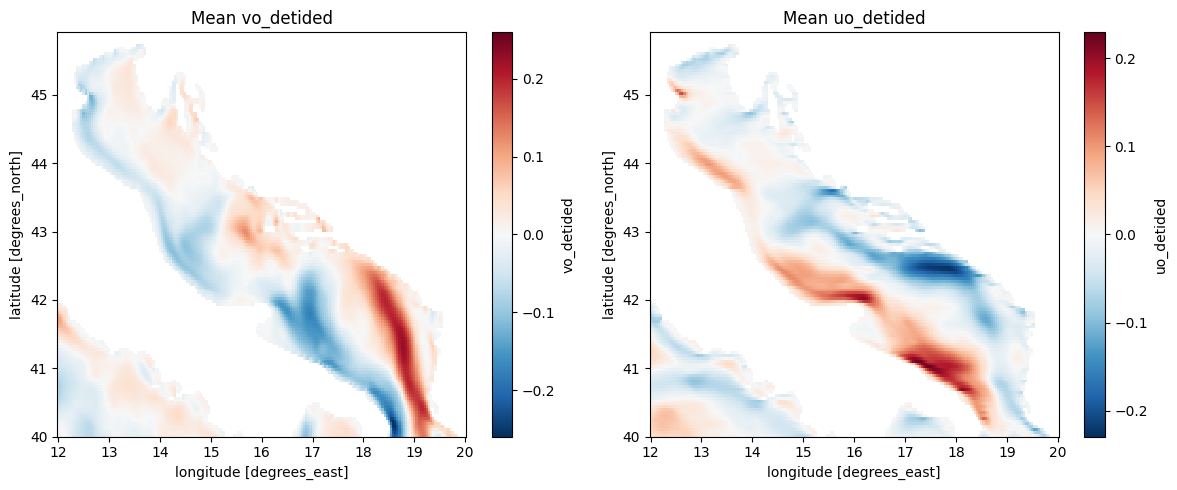

In [ ]:
import matplotlib.pyplot as plt

# Compute mean over time
mean_vo = df_vo['vo_detided'].mean(dim='time')
mean_uo = df_uo['uo_detided'].mean(dim='time')

# Side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# vo_detided
mean_vo.plot(ax=axes[0], cmap='RdBu_r')
axes[0].set_title("Mean vo_detided")

# uo_detided
mean_uo.plot(ax=axes[1], cmap='RdBu_r')
axes[1].set_title("Mean uo_detided")

plt.tight_layout()
plt.show()


In [ ]:
import hvplot.xarray

df_vo['vo_detided'].hvplot.image(x='longitude', y='latitude', frame_width=500, clim=None, widget_type='scrubber', cmap='RdBu_r')


BokehModel(combine_events=True, render_bundle={'docs_json': {'b029e475-b433-4135-9f06-9d629aa87c72': {'version…

In [ ]:
df_uo['uo_detided'].hvplot.image(x='longitude', y='latitude', frame_width=500, clim=None, widget_type='scrubber', cmap='RdBu_r')


BokehModel(combine_events=True, render_bundle={'docs_json': {'86637616-8168-4956-a089-19f6b46d47d3': {'version…